# Notebook Overview

**English**
This notebook focuses on side-channel capture and analysis for ML-KEM workflows on ARM Cortex-M4 targets, mainly CW-Husky + SAM4S (CWHUSKY) and STM32-class M4 setups. It configures ChipWhisperer capture, loads test vectors, executes SimpleSerial2 command flows, and captures traces around decapsulation/cmov behavior for leakage exploration.

**Español**
Este notebook se centra en captura y análisis de canal lateral para flujos ML-KEM en objetivos ARM Cortex-M4, principalmente CW-Husky + SAM4S (CWHUSKY) y configuraciones STM32 de clase M4. Configura la captura con ChipWhisperer, carga vectores de prueba, ejecuta flujos de comandos SimpleSerial2 y captura trazas alrededor del comportamiento de decapsulation/cmov para explorar fugas.
**Português**
Este notebook foca em captura e análise de canal lateral para fluxos ML-KEM em alvos ARM Cortex-M4, principalmente CW-Husky + SAM4S (CWHUSKY) e configurações STM32 de classe M4. Ele configura a captura com ChipWhisperer, carrega vetores de teste, executa fluxos de comandos SimpleSerial2 e captura traços em torno do comportamento de decapsulation/cmov para exploração de vazamentos.


**Objective / Objetivo**
Build a repeatable workflow to validate communication, collect stable traces, and study where secret-dependent operations may leak under practical capture settings.
Construir um fluxo repetível para validar a comunicação, coletar traços estáveis e estudar onde operações dependentes de segredo podem vazar em condições práticas de captura.


## Connect to ChipWhisperer / Conectar a ChipWhisperer

**English:** Initialize the scope and choose the programmer for the active platform before any capture steps.
**Español:** Inicializa el scope y selecciona el programador para la plataforma activa antes de cualquier captura.
**Português:** Inicializa o scope e seleciona o programador da plataforma ativa antes de qualquer etapa de captura.


In [1]:
import chipwhisperer as cw
import time
from pathlib import Path

# PLATFORM examples: CWHUSKY, CW308_STM32F3, CWLITEARM, CWNANO, CWLITEXMEGA
PLATFORM = 'CWHUSKY'
SCOPETYPE = 'OPENADC'

try:
    if not scope.connectStatus:
        scope.con()
except NameError:
    scope = cw.scope()

print('INFO: Scope ready')

def resolve_programmer(platform):
    p = platform.upper()
    # Prefer SAM4S for Husky/SAM targets; use STM32 for STM/ARM targets.
    if any(k in p for k in ('HUSKY', 'SAM4S', 'SAM')):
        return getattr(cw.programmers, 'SAM4SProgrammer', None)
    if any(k in p for k in ('STM', 'ARM', 'CWNANO', 'CWLITEARM')):
        return getattr(cw.programmers, 'STM32FProgrammer', None)
    if any(k in p for k in ('XMEGA', 'CW303')):
        return getattr(cw.programmers, 'XMEGAProgrammer', None)
    return None

def resolve_firmware_hex(platform, base_name='simpleserial-ml-kem-512'):
    candidates = [
        Path(f'{base_name}-{platform}.hex'),
        Path(f'{base_name}-{platform.upper()}.hex'),
        Path(f'{base_name}-{platform.lower()}.hex'),
    ]
    for c in candidates:
        if c.exists():
            return str(c)

    matches = sorted(Path('.').glob(f'{base_name}-*.hex'))
    if len(matches) == 1:
        return str(matches[0])
    if len(matches) > 1:
        hint = ', '.join(m.name for m in matches[:8])
        raise RuntimeError(
            f'Multiple firmware files found; set PLATFORM or choose one explicitly. Candidates: {hint}'
        )
    raise RuntimeError(
        f'No firmware .hex found for PLATFORM={platform}. Build first, e.g. make PLATFORM={platform} CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1'
    )

prog = resolve_programmer(PLATFORM)

def reset_target(scope):
    if PLATFORM.upper() in ('CW303', 'CWLITEXMEGA'):
        scope.io.pdic = 'low'
        time.sleep(0.05)
        scope.io.pdic = 'high_z'
        time.sleep(0.05)
    else:
        scope.io.nrst = 'low'
        time.sleep(0.05)
        scope.io.nrst = 'high_z'
        time.sleep(0.05)


INFO: Scope ready


### Scope Connection Options / Opciones de Conexion del Scope

**English:** This section explains automatic detection and how to select a specific device when multiple boards are connected.
**Español:** Esta seccion explica la deteccion automatica y como seleccionar un dispositivo especifico cuando hay varias placas conectadas.
**Português:** Esta seção explica a detecção automática e como selecionar um dispositivo específico quando há várias placas conectadas.


In [2]:
try:
    target = cw.target(scope, cw.targets.SimpleSerial2)
except IOError:
    print("INFO: Error to reconnect target; reopening scope/target")
    scope = cw.scope()
    target = cw.target(scope, cw.targets.SimpleSerial2)

print("INFO: Found ChipWhisperer and SimpleSerial2 target")

INFO: Found ChipWhisperer and SimpleSerial2 target


### Target Link with SimpleSerial2 / Enlace del Target con SimpleSerial2

**English:** Connect to the target over SimpleSerial2 and recover cleanly if reconnection is required.
**Español:** Conecta al target por SimpleSerial2 y recupera la sesion de forma limpia si se requiere reconexion.
**Português:** Conecta ao alvo via SimpleSerial2 e recupera a sessão de forma limpa se for necessária reconexão.


In [3]:
time.sleep(0.05)
scope.default_setup()
reset_target(scope)

print(f"INFO: default_setup applied for {PLATFORM}")
print(f"INFO: hs2={scope.io.hs2}, tio1={scope.io.tio1}, tio2={scope.io.tio2}")
print(f"INFO: clkgen={scope.clock.clkgen_freq}, adc={scope.clock.adc_freq}")
print(f"INFO: initial errors: {scope.errors}")

scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 327828                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_

### Apply Default Scope Setup / Aplicar Configuracion Base del Scope

**English:** Run default scope settings and print the resulting clock, IO, and error status values.
**Español:** Ejecuta la configuracion base del scope e imprime los valores de reloj, IO y estado de errores.
**Português:** Executa a configuração padrão do scope e imprime os valores de clock, IO e estado de erros.


### Setup Checkpoint / Punto de Control de Configuracion

**English:** At this point the connection path is validated and the notebook is ready to move into firmware and capture workflow.
**Español:** En este punto la ruta de conexion queda validada y el notebook esta listo para pasar al flujo de firmware y captura.
**Português:** Neste ponto, o caminho de conexão está validado e o notebook está pronto para seguir para o fluxo de firmware e captura.


## Build and Flash Firmware / Compilar y Grabar Firmware

**English:** Compile the target firmware for the selected board and prepare it for programming.
**Español:** Compila el firmware objetivo para la placa seleccionada y dejalo listo para programacion.
**Português:** Compila o firmware do alvo para a placa selecionada e prepara para programação.


In [4]:
%%bash
make PLATFORM=CWHUSKY CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1
#make PLATFORM=CW308_STM32F3 CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1

Building for platform CWHUSKY with CRYPTO_TARGET=NONE
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:14.2.rel1-1) 14.2.1 20241119
Copyright (C) 2024 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWHUSKY 
.
Compiling:
-en     simpleserial-ml-kem-512.c ...
-e Done!
.
Compiling:
-en     kem.c ...
-e Done!
.
Compiling:
-en     indcpa.c ...
-e Done!
.
Compiling:
-en     cbd.c ...
-e Done!
.
Compiling:
-en     ntt.c ...
-e Done!
.
Compiling:
-en     poly.c ...
-e Done!
.
Compiling:
-en     polyvec.c ...
-e Done!
.
Compiling:
-en     reduce.c ...
-e Done!
.
Compiling:
-en     symmetric-shake.c ...
-e Done!
.
Compiling:
-en     verify.c ...
-e Done!
.
Compiling:
-en     fips202.c ...
-e Done!
.
Compiling:
-en     randombytes_sam4s.c ...
-e Done!
.
Compiling:
-e

### Build and Programming Notes / Notas de Compilacion y Programacion

**English:** This section clarifies platform selection and shows how to flash the generated image to the target.
**Español:** Esta seccion aclara la seleccion de plataforma y muestra como grabar la imagen generada en el target.
**Português:** Esta seção esclarece a seleção de plataforma e mostra como gravar a imagem gerada no alvo.


In [5]:
fw_hex = resolve_firmware_hex(PLATFORM)

if prog is None:
    raise RuntimeError(
        f'No built-in programmer matched PLATFORM={PLATFORM}. Use external flashing or set prog manually.'
    )

print(f'INFO: Programming {fw_hex} with {prog.__name__}')
cw.program_target(scope, prog, fw_hex)
reset_target(scope)
target.flush()
print(f'INFO: Firmware programmed and target reset for PLATFORM={PLATFORM}')


INFO: Programming simpleserial-ml-kem-512-CWHUSKY.hex with SAM4SProgrammer
INFO: Firmware programmed and target reset for PLATFORM=CWHUSKY


### External Programmer Path / Ruta con Programador Externo

**English:** Use this path when onboard programming is unavailable for your hardware.
**Español:** Usa esta ruta cuando la programacion integrada no esta disponible para tu hardware.
**Português:** Use este caminho quando a programação onboard não estiver disponível para o seu hardware.


## ML-KEM Data Exchange Workflow / Flujo de Intercambio de Datos ML-KEM

**English:** The following cells load SK, PK, CT, and SS vectors via SimpleSerial2 and validate round-trip integrity.
**Español:** Las celdas siguientes cargan vectores SK, PK, CT y SS por SimpleSerial2 y validan la integridad ida-vuelta.
**Português:** As células a seguir carregam vetores SK, PK, CT e SS via SimpleSerial2 e validam a integridade de ida e volta.


In [6]:
sk = bytearray([ 0x9e, 0xe6, 0xc3, 0x79, 0x1c, 0x70, 0x26, 0x36, 0x94, 0x51, 0x05, 0x3f, 0xb6, 0xca, 0x69, 0x2b, 
0xb1, 0x04, 0x0d, 0xa6, 0x78, 0xc9, 0xd2, 0x8e, 0x51, 0x30, 0x40, 0xa0, 0x15, 0x42, 0x91, 0xc5, 
0xba, 0x16, 0x51, 0x5b, 0x3c, 0xa0, 0xc5, 0xf8, 0xc1, 0x1a, 0x53, 0x99, 0x60, 0x11, 0x06, 0x0b, 
0xcc, 0xb3, 0xb0, 0x6b, 0xbb, 0x05, 0xe2, 0x32, 0x97, 0x4d, 0x1c, 0x13, 0x61, 0x33, 0xb5, 0xf3, 
0x35, 0xc2, 0x2b, 0xa4, 0x0e, 0xb2, 0x73, 0xa7, 0x9a, 0x3c, 0xa8, 0x76, 0x99, 0x3a, 0x8a, 0xc6, 
0x6b, 0xd4, 0xc1, 0x82, 0xfd, 0xe1, 0x0d, 0x0e, 0x09, 0xa1, 0xa1, 0xc4, 0x5b, 0x5f, 0xe2, 0xa7, 
0x3f, 0x98, 0x3e, 0x91, 0x60, 0x2a, 0x1e, 0x13, 0xb7, 0x3f, 0xe7, 0xbe, 0x76, 0x09, 0x59, 0x5a, 
0x17, 0xbd, 0x15, 0xd3, 0x90, 0x25, 0x9a, 0xae, 0xbf, 0x2b, 0x32, 0xaf, 0x10, 0x28, 0x9d, 0x99, 
0xb3, 0x03, 0x64, 0xc1, 0x56, 0x23, 0xa7, 0x61, 0x61, 0x78, 0x99, 0x33, 0xa1, 0x1b, 0x07, 0x76, 
0x1f, 0xe5, 0x15, 0x78, 0x57, 0x39, 0x17, 0xa4, 0x91, 0xb3, 0x83, 0x1d, 0xb6, 0x06, 0xc8, 0x5c, 
0x01, 0xa3, 0x71, 0x62, 0x0d, 0x82, 0x89, 0x3f, 0xba, 0x56, 0xb9, 0x16, 0x46, 0x10, 0x2e, 0x86, 
0xaf, 0xf5, 0x54, 0x07, 0x4c, 0xd4, 0x74, 0x0d, 0x28, 0x77, 0x9c, 0x3a, 0x54, 0xb8, 0x6b, 0x22, 
0xdb, 0x60, 0xce, 0x2d, 0x0c, 0x89, 0x71, 0x53, 0xc0, 0xa4, 0x23, 0x6e, 0xa6, 0x27, 0x30, 0xde, 
0xb7, 0xa2, 0x79, 0x7b, 0x5b, 0xb4, 0xb4, 0x8e, 0xf1, 0xfb, 0xb7, 0x3f, 0x18, 0x26, 0xcf, 0x71, 
0x8c, 0x59, 0x53, 0x13, 0x92, 0xf8, 0xc6, 0x9f, 0x98, 0x12, 0xef, 0x04, 0x02, 0xbd, 0xe2, 0x96, 
0xed, 0x52, 0xbc, 0x97, 0xd9, 0x3b, 0x32, 0x97, 0xca, 0x0d, 0x64, 0x47, 0x68, 0xa5, 0x13, 0xf0, 
0x09, 0x3f, 0x88, 0x05, 0x6a, 0x81, 0xc9, 0xc5, 0x2a, 0xc2, 0x6b, 0xe2, 0xe6, 0xc8, 0x8a, 0xfa, 
0x30, 0xf9, 0x83, 0xa5, 0x20, 0x2a, 0x1b, 0x0d, 0x62, 0x29, 0xa8, 0xe2, 0x2c, 0x44, 0x58, 0x4e, 
0xb0, 0xa8, 0x0a, 0xdb, 0xc4, 0xc9, 0x05, 0x33, 0x97, 0xfc, 0x4c, 0x5d, 0xb1, 0x23, 0x01, 0xca, 
0x26, 0x38, 0x98, 0x26, 0x77, 0x13, 0x0a, 0xca, 0x6a, 0xe1, 0x9f, 0xa0, 0x7a, 0x2a, 0xd4, 0xe7, 
0x2f, 0x40, 0x3b, 0xbe, 0xe2, 0x52, 0x58, 0xa7, 0x8a, 0x1a, 0x55, 0x38, 0x4b, 0x1d, 0x8b, 0x11, 
0xf9, 0xa0, 0x4e, 0x54, 0x45, 0x75, 0xd0, 0xd7, 0x4d, 0xe0, 0xe2, 0x39, 0x26, 0x97, 0x6a, 0xb4, 
0x89, 0x29, 0xd4, 0xd7, 0x59, 0x70, 0xd4, 0x0a, 0x01, 0xc4, 0xbe, 0x5e, 0x90, 0x66, 0x0f, 0x09, 
0x2c, 0x3d, 0x47, 0x36, 0x41, 0x75, 0x56, 0xa3, 0xa3, 0x8f, 0x28, 0x31, 0x60, 0x95, 0x9c, 0x66, 
0x2e, 0x12, 0xb1, 0x92, 0x56, 0xae, 0x1d, 0xf4, 0x80, 0x12, 0x88, 0x64, 0x36, 0x65, 0x44, 0xd5, 
0x8a, 0x6a, 0x13, 0x77, 0xc1, 0xf7, 0x11, 0xcc, 0xd3, 0xb7, 0x50, 0xd3, 0x8a, 0x4b, 0x78, 0x31, 
0x90, 0x80, 0xd1, 0x47, 0xcc, 0x3c, 0x0d, 0xe6, 0xc0, 0xc5, 0x3b, 0x6a, 0x7a, 0x26, 0xea, 0x2b, 
0xc5, 0x51, 0x43, 0xc3, 0xd0, 0x53, 0xce, 0x7b, 0x89, 0x38, 0x83, 0x7c, 0x76, 0xaa, 0x49, 0x88, 
0x75, 0x91, 0x1b, 0x2a, 0xa2, 0xc5, 0x77, 0x5e, 0x51, 0xb1, 0x33, 0xde, 0xb1, 0x31, 0xa5, 0xf5, 
0x24, 0xa3, 0x41, 0x34, 0x1d, 0xe7, 0x52, 0xef, 0x57, 0x51, 0x99, 0xf2, 0x3f, 0x4a, 0x88, 0x02, 
0xb2, 0x18, 0x3d, 0xa4, 0xdc, 0xac, 0x39, 0x64, 0x70, 0x37, 0x16, 0x65, 0x8b, 0xf9, 0x33, 0x9a, 
0xab, 0x42, 0xa1, 0x70, 0x1c, 0x2f, 0x56, 0x89, 0xad, 0xfa, 0x72, 0x94, 0x05, 0x15, 0x6c, 0x59, 
0x84, 0x6c, 0xa8, 0x16, 0x27, 0x32, 0x3d, 0x45, 0xa2, 0x11, 0xd7, 0x54, 0x29, 0x9f, 0x87, 0x55, 
0x6b, 0x90, 0x05, 0x60, 0x47, 0x42, 0x9a, 0x06, 0xcd, 0x0b, 0xfb, 0x8f, 0x89, 0x62, 0xbd, 0x6e, 
0xc5, 0x6d, 0x0a, 0x0b, 0x4a, 0x72, 0xb6, 0x35, 0x69, 0x5c, 0xa2, 0xca, 0x1c, 0xbc, 0xee, 0x15, 
0x30, 0xdf, 0xc1, 0x3a, 0x62, 0x89, 0x5a, 0x55, 0x46, 0x86, 0x5b, 0x0a, 0x45, 0xae, 0xa5, 0x5e, 
0xea, 0x89, 0x06, 0xe9, 0xc0, 0x9a, 0xcc, 0x22, 0x1e, 0xd9, 0x74, 0x1c, 0xff, 0xe4, 0xc3, 0x98, 
0xf2, 0xa2, 0x4b, 0x16, 0x09, 0xe3, 0xb0, 0x44, 0xe5, 0x66, 0xcf, 0xbd, 0xd0, 0x99, 0x48, 0x30, 
0x05, 0x1a, 0xf7, 0x76, 0x32, 0x8c, 0x32, 0x07, 0x13, 0x74, 0x29, 0x9c, 0x88, 0x6d, 0xe9, 0x7c, 
0x6a, 0xc3, 0x4c, 0x17, 0x47, 0x7d, 0x82, 0xf6, 0x29, 0xd9, 0x70, 0xc3, 0x86, 0x75, 0x18, 0xa7, 
0xd6, 0x32, 0x96, 0x69, 0x96, 0x14, 0xc8, 0xca, 0x6d, 0x3c, 0x57, 0x90, 0xc3, 0x86, 0xac, 0x3c, 
0x42, 0x14, 0xb3, 0x32, 0xd0, 0xa2, 0x5d, 0x3d, 0x26, 0x06, 0x06, 0x60, 0x15, 0xf3, 0x92, 0x2d, 
0x0e, 0x88, 0x0f, 0x83, 0x08, 0x88, 0x3e, 0x5b, 0x86, 0xf5, 0x84, 0x19, 0x98, 0xda, 0x0b, 0xa8, 
0xb9, 0x9a, 0x57, 0xc0, 0x45, 0xb3, 0x25, 0xbf, 0x67, 0xb3, 0x77, 0xbd, 0x53, 0x8a, 0xb3, 0xf4, 
0x2d, 0x34, 0x55, 0x57, 0xbf, 0x49, 0xb2, 0x22, 0x16, 0x78, 0x00, 0xbc, 0x6f, 0x7c, 0x67, 0x12, 
0x1a, 0x71, 0x36, 0x92, 0xa6, 0xc9, 0xd9, 0x60, 0x81, 0xab, 0xf8, 0x17, 0xd1, 0x00, 0x15, 0x6a, 
0xc1, 0x73, 0x06, 0x06, 0x57, 0x40, 0x5c, 0xa8, 0xd6, 0x3a, 0x1c, 0xcc, 0xc7, 0x03, 0x95, 0x94, 
0x89, 0x88, 0xd7, 0xaf, 0x02, 0x4b, 0x32, 0x2d, 0x55, 0x44, 0x93, 0x95, 0xa1, 0xb0, 0xdb, 0x05, 
0x37, 0xd9, 0x19, 0x17, 0x5a, 0xbe, 0x88, 0x62, 0x23, 0x11, 0x95, 0x5f, 0xb0, 0xac, 0x55, 0xef, 
0x8a, 0x23, 0x53, 0xb9, 0x70, 0x05, 0x69, 0x86, 0x0a, 0xb1, 0x08, 0x2e, 0x0b, 0x73, 0x2c, 0xba, 
0x27, 0x25, 0x1b, 0x5f, 0xa0, 0x95, 0xc4, 0xb2, 0x32, 0x8a, 0x11, 0x81, 0x96, 0xfe, 0x05, 0xc4, 
0xdd, 0x1a, 0x68, 0x80, 0x35, 0x8f, 0x41, 0x84, 0xc0, 0xa9, 0x68, 0xa8, 0xa0, 0x37, 0x11, 0x90, 
0x26, 0x19, 0x18, 0xe6, 0x0c, 0xd9, 0xf9, 0x93, 0x2b, 0x5c, 0x36, 0xaa, 0x4a, 0x27, 0xe7, 0x21, 
0x8d, 0xaa, 0x73, 0x9a, 0x03, 0x10, 0xcb, 0x0c, 0x5a, 0x06, 0xd5, 0x6a, 0x47, 0xa6, 0x73, 0x4e, 
0x95, 0xd1, 0x7e, 0xd5, 0xdc, 0x50, 0x66, 0xa4, 0x5f, 0x19, 0x88, 0x63, 0x79, 0xe8, 0x59, 0xb6, 
0x00, 0x35, 0x0e, 0xd1, 0x1c, 0x31, 0x78, 0x91, 0x38, 0xf4, 0x92, 0x42, 0x88, 0x7c, 0xe8, 0xe6, 
0x00, 0xa6, 0xb4, 0xc7, 0xaa, 0xa0, 0x30, 0x92, 0xe0, 0xc5, 0x4a, 0x5a, 0x3e, 0x3d, 0x32, 0x2a, 
0x15, 0x32, 0xa9, 0xaa, 0x46, 0x96, 0xe3, 0xb1, 0x5c, 0xf2, 0x41, 0x16, 0x83, 0xdb, 0x87, 0x0a, 
0x39, 0xa8, 0x34, 0xa1, 0x42, 0x72, 0x76, 0x9c, 0xa6, 0x1a, 0xa4, 0x03, 0x55, 0xaa, 0x6e, 0x29, 
0x9c, 0x9f, 0x16, 0x99, 0xb8, 0x30, 0x7a, 0x49, 0x5a, 0x49, 0xc9, 0x71, 0x78, 0x19, 0x37, 0x4b, 
0xf3, 0xa9, 0xa3, 0xa4, 0xc7, 0x04, 0xbc, 0xe2, 0x5e, 0xb5, 0xf3, 0x87, 0x08, 0x51, 0x3d, 0x8a, 
0x37, 0x4b, 0x3d, 0x93, 0x5b, 0x9c, 0x41, 0xca, 0xc7, 0xf3, 0x82, 0xcf, 0xb9, 0x6b, 0x0e, 0x33, 
0x1e, 0x7e, 0x67, 0x57, 0x8f, 0x35, 0xa3, 0x31, 0x30, 0x2e, 0x12, 0xab, 0x2b, 0x67, 0x33, 0x1c, 
0x64, 0x1a, 0xb8, 0x4c, 0x0c, 0x6f, 0xf7, 0xa4, 0x0b, 0x90, 0x39, 0x86, 0xcd, 0x07, 0x7b, 0xb6, 
0x7b, 0xc1, 0x76, 0x26, 0xae, 0x36, 0x53, 0x97, 0x1e, 0xa2, 0x1d, 0x9c, 0x6b, 0xad, 0xcc, 0x3c, 
0xb6, 0x7b, 0xf4, 0x74, 0xfa, 0xa6, 0x8c, 0xf9, 0x91, 0x4f, 0x5c, 0x96, 0x8a, 0x67, 0xb7, 0x73, 
0x84, 0x61, 0x73, 0xa8, 0x55, 0x97, 0xbf, 0x63, 0x63, 0x8f, 0x26, 0x82, 0xd8, 0xaa, 0xbf, 0xc2, 
0xf2, 0x39, 0xd7, 0x44, 0x7e, 0xcf, 0x07, 0xc7, 0xd9, 0x88, 0xc2, 0x9b, 0xb1, 0x15, 0x4a, 0x9a, 
0x94, 0x61, 0xfa, 0x0c, 0xec, 0xac, 0x79, 0xea, 0x67, 0xb7, 0x7f, 0x55, 0xc0, 0xe1, 0x66, 0xad, 
0xc7, 0x08, 0x73, 0xe1, 0x47, 0x18, 0xba, 0x4a, 0x0b, 0x71, 0x10, 0x5e, 0xbc, 0xbc, 0xaf, 0xec, 
0x56, 0xa4, 0x91, 0x72, 0x37, 0xfb, 0xb8, 0x78, 0xa7, 0x08, 0x4b, 0xed, 0xc3, 0xa5, 0x1f, 0x88, 
0xc8, 0x52, 0x31, 0x57, 0xc9, 0x6a, 0x59, 0xae, 0xeb, 0x04, 0xc6, 0x64, 0x95, 0x83, 0xf0, 0x5a, 
0x89, 0x0c, 0xbe, 0xe6, 0x33, 0x2f, 0xbb, 0x12, 0x16, 0x78, 0x15, 0x40, 0x61, 0x55, 0x96, 0x3f, 
0x41, 0x56, 0x49, 0x60, 0x49, 0x22, 0xdc, 0xcb, 0x6a, 0xd8, 0x05, 0xe1, 0x37, 0xa5, 0x37, 0x81, 
0xc4, 0x72, 0xf2, 0x1b, 0x68, 0x52, 0x4c, 0x12, 0xe1, 0x96, 0xbf, 0x78, 0x0c, 0xfd, 0xec, 0x97, 
0x8f, 0xa1, 0x87, 0xf4, 0x87, 0x38, 0x67, 0x80, 0x9d, 0x17, 0x84, 0x3c, 0x05, 0x6c, 0x5d, 0x0c, 
0x83, 0x5f, 0xbd, 0x7c, 0xca, 0x9d, 0x28, 0x1d, 0x80, 0xb5, 0x83, 0x79, 0x52, 0x5e, 0x6a, 0x42, 
0xbf, 0xe8, 0x90, 0x3b, 0xa2, 0xa5, 0x65, 0xdc, 0xc6, 0x78, 0xe9, 0x47, 0x7e, 0x0f, 0xcb, 0x49, 
0xb8, 0x9a, 0x3e, 0x59, 0x09, 0x2f, 0x5b, 0xa8, 0x42, 0x29, 0x36, 0x7d, 0x74, 0x1b, 0x08, 0x14, 
0x2b, 0xb1, 0xa3, 0x7c, 0x0f, 0xe0, 0x11, 0xc8, 0xe7, 0xfa, 0xcf, 0x5c, 0xfc, 0x40, 0x35, 0x3a, 
0x8b, 0x3a, 0xd0, 0xc7, 0xfb, 0x99, 0x13, 0x2f, 0x23, 0x48, 0x2a, 0x44, 0x0b, 0x5f, 0x6a, 0x5b, 
0xa0, 0x44, 0x0d, 0xeb, 0x92, 0x5a, 0xca, 0x62, 0x55, 0xb6, 0x1b, 0x92, 0xb9, 0x04, 0x55, 0xcf, 
0x22, 0x3b, 0x08, 0x09, 0xb7, 0xdd, 0xbc, 0x2a, 0x8e, 0xf5, 0xc3, 0x57, 0x38, 0x90, 0xf3, 0x94, 
0x93, 0x06, 0x50, 0xaf, 0xbd, 0x6a, 0x5d, 0x72, 0xb0, 0x23, 0x3a, 0xb4, 0x01, 0xe5, 0x47, 0x63, 
0xfc, 0x93, 0x07, 0x71, 0x23, 0xb9, 0x76, 0x61, 0x10, 0xc6, 0x93, 0x3c, 0xed, 0xf1, 0x8d, 0x58, 
0x6c, 0x14, 0xe9, 0x81, 0x23, 0x76, 0xfa, 0x31, 0x0d, 0x2c, 0x14, 0x42, 0xc6, 0xaa, 0x8e, 0x50, 
0xb4, 0x63, 0x3a, 0xa3, 0x8c, 0x03, 0xad, 0x10, 0x90, 0x1e, 0x72, 0x3c, 0xa5, 0x85, 0xb5, 0x30, 
0x87, 0x87, 0xad, 0xdf, 0x12, 0x5c, 0x5d, 0x49, 0x91, 0x8b, 0x54, 0xba, 0x9b, 0xc1, 0x38, 0xa6, 
0x95, 0xad, 0x42, 0x14, 0x1b, 0x59, 0x51, 0x44, 0x9a, 0xf8, 0x80, 0x44, 0x04, 0x27, 0x6f, 0x81, 
0x4a, 0x42, 0x42, 0xc2, 0xd0, 0x59, 0x65, 0x4a, 0xac, 0x69, 0x0e, 0x73, 0x23, 0xb9, 0x62, 0xbb, 
0x58, 0xf3, 0x97, 0x76, 0x5c, 0x87, 0xf8, 0x10, 0xa8, 0xa6, 0x85, 0x0d, 0x65, 0x93, 0x6a, 0x63, 
0x66, 0x58, 0xee, 0x49, 0xc7, 0xa6, 0x05, 0xcf, 0x9f, 0x7b, 0x1d, 0xcf, 0xfb, 0x7c, 0xa7, 0x27, 
0xc4, 0x25, 0x82, 0xa6, 0x5b, 0x09, 0x26, 0x0a, 0x12, 0xb5, 0xa3, 0xd3, 0x1b, 0x8f, 0xb6, 0x85, 
0xc9, 0x0b, 0x25, 0xec, 0x6c, 0xa7, 0x37, 0x77, 0x3d, 0x7a, 0xb0, 0x74, 0x0c, 0xc0, 0xaa, 0x99, 
0xb4, 0x0e, 0x67, 0x10, 0xaa, 0xce, 0xe5, 0x6a, 0x0b, 0xb7, 0x15, 0x2c, 0xec, 0x6c, 0x51, 0x36, 
0x46, 0xb2, 0x0c, 0x63, 0xc7, 0xba, 0x25, 0x88, 0xa0, 0x3b, 0x70, 0xf5, 0x73, 0x08, 0xaa, 0x28, 
0xf9, 0xf2, 0xca, 0x92, 0x15, 0xfd, 0x6c, 0xd0, 0x6d, 0xe6, 0x7f, 0x25, 0xf6, 0x88, 0xa3, 0x9f, 
0xfe, 0x3b, 0x0e, 0x36, 0xd4, 0x58, 0x07, 0xae, 0x9c, 0xf0, 0x06, 0x75, 0x5f, 0xdf, 0x01, 0x35, 
0x60, 0x54, 0x5f, 0x0c, 0x4b, 0xd4, 0x51, 0x81, 0x45, 0x8b, 0x3a, 0xe8, 0xa1, 0x3a, 0x3d, 0xf3, 
0x78, 0xf2, 0x10, 0x09, 0x2b, 0xe7, 0x96, 0xaf, 0x2d, 0x7c, 0x46, 0xa6, 0xd7, 0x6c, 0x8e, 0xaa, 
0x6e, 0x53, 0x5f, 0x4c, 0x8d, 0x38, 0x13, 0x98, 0xec, 0x75, 0x9a, 0xdf, 0x4e, 0x27, 0xb0, 0x19, 
0x1d, 0xf7, 0xe4, 0x0e, 0x53, 0x1e, 0x6c, 0x18, 0x7a, 0xbd, 0x07, 0x21, 0xf6, 0xcd, 0xf6, 0x59
 ])

pk = bytearray([ 0x37, 0xd9, 0x19, 0x17, 0x5a, 0xbe, 0x88, 0x62, 0x23, 0x11, 0x95, 0x5f, 0xb0, 0xac, 0x55, 0xef, 
0x8a, 0x23, 0x53, 0xb9, 0x70, 0x05, 0x69, 0x86, 0x0a, 0xb1, 0x08, 0x2e, 0x0b, 0x73, 0x2c, 0xba, 
0x27, 0x25, 0x1b, 0x5f, 0xa0, 0x95, 0xc4, 0xb2, 0x32, 0x8a, 0x11, 0x81, 0x96, 0xfe, 0x05, 0xc4, 
0xdd, 0x1a, 0x68, 0x80, 0x35, 0x8f, 0x41, 0x84, 0xc0, 0xa9, 0x68, 0xa8, 0xa0, 0x37, 0x11, 0x90, 
0x26, 0x19, 0x18, 0xe6, 0x0c, 0xd9, 0xf9, 0x93, 0x2b, 0x5c, 0x36, 0xaa, 0x4a, 0x27, 0xe7, 0x21, 
0x8d, 0xaa, 0x73, 0x9a, 0x03, 0x10, 0xcb, 0x0c, 0x5a, 0x06, 0xd5, 0x6a, 0x47, 0xa6, 0x73, 0x4e, 
0x95, 0xd1, 0x7e, 0xd5, 0xdc, 0x50, 0x66, 0xa4, 0x5f, 0x19, 0x88, 0x63, 0x79, 0xe8, 0x59, 0xb6, 
0x00, 0x35, 0x0e, 0xd1, 0x1c, 0x31, 0x78, 0x91, 0x38, 0xf4, 0x92, 0x42, 0x88, 0x7c, 0xe8, 0xe6, 
0x00, 0xa6, 0xb4, 0xc7, 0xaa, 0xa0, 0x30, 0x92, 0xe0, 0xc5, 0x4a, 0x5a, 0x3e, 0x3d, 0x32, 0x2a, 
0x15, 0x32, 0xa9, 0xaa, 0x46, 0x96, 0xe3, 0xb1, 0x5c, 0xf2, 0x41, 0x16, 0x83, 0xdb, 0x87, 0x0a, 
0x39, 0xa8, 0x34, 0xa1, 0x42, 0x72, 0x76, 0x9c, 0xa6, 0x1a, 0xa4, 0x03, 0x55, 0xaa, 0x6e, 0x29, 
0x9c, 0x9f, 0x16, 0x99, 0xb8, 0x30, 0x7a, 0x49, 0x5a, 0x49, 0xc9, 0x71, 0x78, 0x19, 0x37, 0x4b, 
0xf3, 0xa9, 0xa3, 0xa4, 0xc7, 0x04, 0xbc, 0xe2, 0x5e, 0xb5, 0xf3, 0x87, 0x08, 0x51, 0x3d, 0x8a, 
0x37, 0x4b, 0x3d, 0x93, 0x5b, 0x9c, 0x41, 0xca, 0xc7, 0xf3, 0x82, 0xcf, 0xb9, 0x6b, 0x0e, 0x33, 
0x1e, 0x7e, 0x67, 0x57, 0x8f, 0x35, 0xa3, 0x31, 0x30, 0x2e, 0x12, 0xab, 0x2b, 0x67, 0x33, 0x1c, 
0x64, 0x1a, 0xb8, 0x4c, 0x0c, 0x6f, 0xf7, 0xa4, 0x0b, 0x90, 0x39, 0x86, 0xcd, 0x07, 0x7b, 0xb6, 
0x7b, 0xc1, 0x76, 0x26, 0xae, 0x36, 0x53, 0x97, 0x1e, 0xa2, 0x1d, 0x9c, 0x6b, 0xad, 0xcc, 0x3c, 
0xb6, 0x7b, 0xf4, 0x74, 0xfa, 0xa6, 0x8c, 0xf9, 0x91, 0x4f, 0x5c, 0x96, 0x8a, 0x67, 0xb7, 0x73, 
0x84, 0x61, 0x73, 0xa8, 0x55, 0x97, 0xbf, 0x63, 0x63, 0x8f, 0x26, 0x82, 0xd8, 0xaa, 0xbf, 0xc2, 
0xf2, 0x39, 0xd7, 0x44, 0x7e, 0xcf, 0x07, 0xc7, 0xd9, 0x88, 0xc2, 0x9b, 0xb1, 0x15, 0x4a, 0x9a, 
0x94, 0x61, 0xfa, 0x0c, 0xec, 0xac, 0x79, 0xea, 0x67, 0xb7, 0x7f, 0x55, 0xc0, 0xe1, 0x66, 0xad, 
0xc7, 0x08, 0x73, 0xe1, 0x47, 0x18, 0xba, 0x4a, 0x0b, 0x71, 0x10, 0x5e, 0xbc, 0xbc, 0xaf, 0xec, 
0x56, 0xa4, 0x91, 0x72, 0x37, 0xfb, 0xb8, 0x78, 0xa7, 0x08, 0x4b, 0xed, 0xc3, 0xa5, 0x1f, 0x88, 
0xc8, 0x52, 0x31, 0x57, 0xc9, 0x6a, 0x59, 0xae, 0xeb, 0x04, 0xc6, 0x64, 0x95, 0x83, 0xf0, 0x5a, 
0x89, 0x0c, 0xbe, 0xe6, 0x33, 0x2f, 0xbb, 0x12, 0x16, 0x78, 0x15, 0x40, 0x61, 0x55, 0x96, 0x3f, 
0x41, 0x56, 0x49, 0x60, 0x49, 0x22, 0xdc, 0xcb, 0x6a, 0xd8, 0x05, 0xe1, 0x37, 0xa5, 0x37, 0x81, 
0xc4, 0x72, 0xf2, 0x1b, 0x68, 0x52, 0x4c, 0x12, 0xe1, 0x96, 0xbf, 0x78, 0x0c, 0xfd, 0xec, 0x97, 
0x8f, 0xa1, 0x87, 0xf4, 0x87, 0x38, 0x67, 0x80, 0x9d, 0x17, 0x84, 0x3c, 0x05, 0x6c, 0x5d, 0x0c, 
0x83, 0x5f, 0xbd, 0x7c, 0xca, 0x9d, 0x28, 0x1d, 0x80, 0xb5, 0x83, 0x79, 0x52, 0x5e, 0x6a, 0x42, 
0xbf, 0xe8, 0x90, 0x3b, 0xa2, 0xa5, 0x65, 0xdc, 0xc6, 0x78, 0xe9, 0x47, 0x7e, 0x0f, 0xcb, 0x49, 
0xb8, 0x9a, 0x3e, 0x59, 0x09, 0x2f, 0x5b, 0xa8, 0x42, 0x29, 0x36, 0x7d, 0x74, 0x1b, 0x08, 0x14, 
0x2b, 0xb1, 0xa3, 0x7c, 0x0f, 0xe0, 0x11, 0xc8, 0xe7, 0xfa, 0xcf, 0x5c, 0xfc, 0x40, 0x35, 0x3a, 
0x8b, 0x3a, 0xd0, 0xc7, 0xfb, 0x99, 0x13, 0x2f, 0x23, 0x48, 0x2a, 0x44, 0x0b, 0x5f, 0x6a, 0x5b, 
0xa0, 0x44, 0x0d, 0xeb, 0x92, 0x5a, 0xca, 0x62, 0x55, 0xb6, 0x1b, 0x92, 0xb9, 0x04, 0x55, 0xcf, 
0x22, 0x3b, 0x08, 0x09, 0xb7, 0xdd, 0xbc, 0x2a, 0x8e, 0xf5, 0xc3, 0x57, 0x38, 0x90, 0xf3, 0x94, 
0x93, 0x06, 0x50, 0xaf, 0xbd, 0x6a, 0x5d, 0x72, 0xb0, 0x23, 0x3a, 0xb4, 0x01, 0xe5, 0x47, 0x63, 
0xfc, 0x93, 0x07, 0x71, 0x23, 0xb9, 0x76, 0x61, 0x10, 0xc6, 0x93, 0x3c, 0xed, 0xf1, 0x8d, 0x58, 
0x6c, 0x14, 0xe9, 0x81, 0x23, 0x76, 0xfa, 0x31, 0x0d, 0x2c, 0x14, 0x42, 0xc6, 0xaa, 0x8e, 0x50, 
0xb4, 0x63, 0x3a, 0xa3, 0x8c, 0x03, 0xad, 0x10, 0x90, 0x1e, 0x72, 0x3c, 0xa5, 0x85, 0xb5, 0x30, 
0x87, 0x87, 0xad, 0xdf, 0x12, 0x5c, 0x5d, 0x49, 0x91, 0x8b, 0x54, 0xba, 0x9b, 0xc1, 0x38, 0xa6, 
0x95, 0xad, 0x42, 0x14, 0x1b, 0x59, 0x51, 0x44, 0x9a, 0xf8, 0x80, 0x44, 0x04, 0x27, 0x6f, 0x81, 
0x4a, 0x42, 0x42, 0xc2, 0xd0, 0x59, 0x65, 0x4a, 0xac, 0x69, 0x0e, 0x73, 0x23, 0xb9, 0x62, 0xbb, 
0x58, 0xf3, 0x97, 0x76, 0x5c, 0x87, 0xf8, 0x10, 0xa8, 0xa6, 0x85, 0x0d, 0x65, 0x93, 0x6a, 0x63, 
0x66, 0x58, 0xee, 0x49, 0xc7, 0xa6, 0x05, 0xcf, 0x9f, 0x7b, 0x1d, 0xcf, 0xfb, 0x7c, 0xa7, 0x27, 
0xc4, 0x25, 0x82, 0xa6, 0x5b, 0x09, 0x26, 0x0a, 0x12, 0xb5, 0xa3, 0xd3, 0x1b, 0x8f, 0xb6, 0x85, 
0xc9, 0x0b, 0x25, 0xec, 0x6c, 0xa7, 0x37, 0x77, 0x3d, 0x7a, 0xb0, 0x74, 0x0c, 0xc0, 0xaa, 0x99, 
0xb4, 0x0e, 0x67, 0x10, 0xaa, 0xce, 0xe5, 0x6a, 0x0b, 0xb7, 0x15, 0x2c, 0xec, 0x6c, 0x51, 0x36, 
0x46, 0xb2, 0x0c, 0x63, 0xc7, 0xba, 0x25, 0x88, 0xa0, 0x3b, 0x70, 0xf5, 0x73, 0x08, 0xaa, 0x28, 
0xf9, 0xf2, 0xca, 0x92, 0x15, 0xfd, 0x6c, 0xd0, 0x6d, 0xe6, 0x7f, 0x25, 0xf6, 0x88, 0xa3, 0x9f, 
0xfe, 0x3b, 0x0e, 0x36, 0xd4, 0x58, 0x07, 0xae, 0x9c, 0xf0, 0x06, 0x75, 0x5f, 0xdf, 0x01, 0x35
 ]);

ct = bytearray([0x59, 0xb3, 0x24, 0x48, 0x5c, 0xac, 0xeb, 0xed, 0x25, 0x86, 0x30, 0x33, 0x4e, 0x19, 0x79, 0xd5, 
0xaa, 0xed, 0x94, 0xf8, 0x4a, 0xdd, 0xa8, 0x14, 0x5c, 0x61, 0x01, 0x3a, 0x03, 0x81, 0x23, 0xc1, 
0xad, 0x46, 0x89, 0x77, 0x90, 0x7a, 0xae, 0x91, 0xf3, 0x53, 0xeb, 0xd0, 0x58, 0x57, 0x75, 0xe2, 
0x94, 0x32, 0x85, 0xd4, 0xfc, 0x53, 0x7b, 0x35, 0xd3, 0xec, 0x81, 0x94, 0x57, 0xcd, 0xae, 0x06, 
0xfd, 0xb4, 0xad, 0x0d, 0xba, 0x0a, 0x7b, 0x7c, 0x87, 0x0a, 0xb8, 0x12, 0x12, 0xb6, 0x1b, 0xb0, 
0xcf, 0x5d, 0x52, 0x0b, 0x8d, 0x12, 0x8c, 0xea, 0xac, 0x8e, 0x6f, 0x47, 0xb1, 0x64, 0x09, 0xdd, 
0x7c, 0x2b, 0x8e, 0xb0, 0xc4, 0xb7, 0xbe, 0xb1, 0xca, 0x78, 0x00, 0x18, 0xd9, 0x30, 0xd2, 0xbe, 
0x7f, 0xe8, 0x28, 0xbd, 0x64, 0xe4, 0x3d, 0x4a, 0x51, 0xd3, 0xdd, 0x56, 0x69, 0x5c, 0x12, 0x9b, 
0xcf, 0x50, 0xb9, 0x2a, 0xf5, 0x2c, 0xce, 0xd2, 0x09, 0x26, 0x20, 0x54, 0xe9, 0x21, 0xcd, 0xd2, 
0xee, 0x42, 0xd8, 0xf8, 0x82, 0xbf, 0xca, 0x9b, 0x29, 0x93, 0x6d, 0xa1, 0x10, 0x78, 0x94, 0xc4, 
0x1f, 0xc2, 0xb7, 0x6b, 0x0a, 0x98, 0x79, 0x26, 0x70, 0xb1, 0xe7, 0x7d, 0xab, 0x06, 0x9e, 0xbc, 
0x7a, 0x46, 0x5a, 0x4f, 0x86, 0xe4, 0xa4, 0xb3, 0xff, 0x20, 0x2a, 0x80, 0x27, 0x51, 0xbd, 0x3e, 
0x6e, 0xe4, 0x58, 0x34, 0x79, 0x15, 0x34, 0xee, 0xd6, 0xac, 0x1c, 0x32, 0x4c, 0x92, 0xde, 0x05, 
0x1d, 0xf9, 0x60, 0xbc, 0xc2, 0xe3, 0xf9, 0x5c, 0x79, 0xee, 0x0e, 0x14, 0xdf, 0x75, 0x2d, 0xe3, 
0xea, 0xd2, 0x39, 0x51, 0x54, 0xfa, 0x01, 0x26, 0xbd, 0xb5, 0xd3, 0xfe, 0x59, 0x79, 0x08, 0x73, 
0x1f, 0x84, 0x1b, 0xc2, 0x37, 0x6a, 0xbb, 0x29, 0xb4, 0xd2, 0x2a, 0xc8, 0x5e, 0xeb, 0x7f, 0xc0, 
0x5b, 0xef, 0xad, 0x1f, 0xfb, 0xb1, 0xb8, 0x9c, 0x69, 0x0a, 0x69, 0x62, 0xe5, 0xc2, 0x97, 0x87, 
0x5d, 0x33, 0x03, 0x40, 0x40, 0x47, 0xf8, 0x69, 0xb8, 0x83, 0x4f, 0x0d, 0x83, 0xc8, 0x8a, 0xdb, 
0x21, 0x15, 0xe3, 0x31, 0xe4, 0x61, 0x34, 0x7d, 0x1b, 0x0b, 0xfa, 0x63, 0x85, 0x84, 0x8f, 0xf3, 
0x8d, 0x41, 0xd9, 0xb7, 0xa7, 0x39, 0x3a, 0x1d, 0xa1, 0xec, 0x3e, 0xec, 0x21, 0x58, 0x83, 0xf8, 
0xde, 0x67, 0x4e, 0xde, 0x0e, 0x92, 0xae, 0x46, 0x41, 0x49, 0x2a, 0x4b, 0x9e, 0x58, 0x8d, 0x0d, 
0xc5, 0x2b, 0x96, 0xfd, 0x7f, 0xc5, 0x8f, 0xdc, 0xc7, 0xe7, 0x78, 0x56, 0x65, 0xf9, 0xe8, 0x1a, 
0x5b, 0x4a, 0x2b, 0x6d, 0xf5, 0xe4, 0x44, 0xfe, 0x7a, 0xf8, 0x91, 0x4c, 0x43, 0x4b, 0x5c, 0x15, 
0x36, 0xe4, 0xa6, 0xe1, 0xad, 0xc8, 0xba, 0x4d, 0xdd, 0xe2, 0xfd, 0x8c, 0xc2, 0x79, 0xb1, 0x1a, 
0xe5, 0x2f, 0x03, 0x17, 0xab, 0xd0, 0xeb, 0x79, 0x9b, 0xbf, 0xeb, 0x79, 0x5a, 0x33, 0xd7, 0x57, 
0x30, 0x1d, 0x24, 0x8b, 0x0e, 0xc6, 0x67, 0x5b, 0x10, 0xe5, 0xba, 0x5e, 0x25, 0x0f, 0x74, 0x7d, 
0x9a, 0xcc, 0x21, 0x4d, 0x5d, 0xd0, 0x96, 0xf6, 0xf6, 0xdc, 0xdc, 0xca, 0xef, 0x11, 0xd3, 0x52, 
0xc6, 0x28, 0x89, 0x5b, 0x7a, 0xae, 0x1b, 0x78, 0x99, 0x84, 0x61, 0x9d, 0x9e, 0x51, 0x55, 0xb3, 
0x98, 0xd9, 0x2e, 0x53, 0x37, 0xd2, 0xc9, 0xb3, 0xd6, 0x1f, 0x2e, 0x32, 0xc5, 0x18, 0x3e, 0x91, 
0xc4, 0x18, 0xc2, 0x59, 0x0f, 0x2f, 0x6f, 0xa3, 0x45, 0x6a, 0x28, 0x4d, 0x7b, 0xc6, 0xf2, 0xa9, 
0x5c, 0xbf, 0x12, 0x5a, 0x1d, 0x39, 0x64, 0x92, 0x9c, 0x16, 0xd5, 0x1d, 0x89, 0xee, 0x4d, 0x78, 
0xe4, 0xc4, 0x4d, 0xa5, 0xd1, 0x90, 0xf8, 0x78, 0x12, 0xee, 0x1f, 0xf7, 0x95, 0xee, 0xcb, 0x0e, 
0xe2, 0xe7, 0x5d, 0x6c, 0xe8, 0x98, 0x9c, 0x78, 0x89, 0xf3, 0x7f, 0xee, 0xf9, 0xac, 0xfb, 0xa4, 
0xe0, 0xbb, 0xda, 0x31, 0x59, 0x76, 0xdc, 0xd3, 0x2a, 0xec, 0xe3, 0x24, 0xf1, 0x73, 0x7f, 0x33, 
0x1f, 0x6f, 0x2b, 0x2d, 0xa9, 0x43, 0xf4, 0xd7, 0x74, 0x5f, 0x67, 0xd1, 0x5f, 0x6b, 0x79, 0x39, 
0x86, 0xe0, 0x9d, 0x8c, 0xa0, 0x80, 0xba, 0x5f, 0xfc, 0xdb, 0x83, 0x9c, 0x4b, 0x75, 0x94, 0x87, 
0xc4, 0x52, 0x18, 0x81, 0xff, 0x68, 0xd0, 0xe2, 0xdd, 0xfc, 0x42, 0x89, 0x1d, 0x2d, 0x70, 0x94, 
0xf7, 0x62, 0xd9, 0x11, 0xdd, 0x89, 0x5b, 0x67, 0x67, 0xc0, 0xa1, 0xf6, 0xab, 0x4f, 0xb0, 0x6c, 
0x8e, 0x7c, 0x68, 0x6e, 0x96, 0x99, 0xea, 0x61, 0xa3, 0x74, 0x7e, 0xaf, 0x2d, 0x4a, 0x62, 0xc6, 
0x25, 0x68, 0xb2, 0x39, 0x79, 0x60, 0xda, 0xbe, 0x8e, 0x83, 0xe2, 0x7f, 0xd7, 0xfc, 0x54, 0xdf, 
0x5f, 0x5e, 0xbd, 0xd8, 0x53, 0x88, 0xec, 0xbb, 0x55, 0x93, 0xd0, 0x88, 0xd4, 0x89, 0x8a, 0x64, 
0x6c, 0xcd, 0xde, 0x9f, 0x60, 0x3a, 0xd8, 0xc9, 0x10, 0x7a, 0x10, 0xde, 0x96, 0xe6, 0x49, 0x0e, 
0x99, 0xd2, 0x63, 0x36, 0x2c, 0x21, 0x93, 0x5d, 0x5a, 0x9e, 0x3b, 0xa5, 0x0f, 0x37, 0x58, 0x4e, 
0xf2, 0xd0, 0x72, 0xe1, 0xda, 0x19, 0xd2, 0x3c, 0x80, 0xc6, 0x71, 0x94, 0x25, 0x5a, 0x2f, 0x3d, 
0x54, 0xea, 0x40, 0x84, 0xcc, 0xa0, 0x8f, 0x5f, 0x98, 0xc7, 0xf1, 0xeb, 0x6e, 0xe8, 0x8b, 0xae, 
0xbd, 0x96, 0x21, 0xd1, 0x40, 0xbd, 0x2d, 0xf6, 0xb0, 0x6b, 0x5e, 0x41, 0xe1, 0x7f, 0x83, 0x18, 
0x56, 0xd1, 0xe5, 0x38, 0x58, 0xaf, 0x53, 0x5b, 0x1a, 0x79, 0xae, 0x4e, 0xc3, 0x61, 0x8d, 0xa1, 
0xa0, 0xf9, 0x8b, 0x6c, 0x7f, 0x67, 0x52, 0x5c, 0xe5, 0x61, 0xc1, 0x6f, 0x18, 0x95, 0x3a, 0xe9])

ss = bytearray([ 0xf9, 0x37, 0x61, 0xbc, 0x96, 0xdf, 0x73, 0x4d, 0x86, 0xa5, 0x6b, 0xc2, 0x9e, 0xd3, 0xb4, 0x63, 
0x73, 0x07, 0x36, 0x43, 0x37, 0xf3, 0xfd, 0x57, 0xe2, 0x7a, 0x1b, 0x42, 0x65, 0x1c, 0xa5, 0x27
])

In [7]:
SK_LEN = 1632
chunk_size = 100  # ES: <=100 solo aplica a SAM4S para reducir UART overrun; EN: <=100 only applies to SAM4S to reduce UART overrun risk; PT: <=100 aplica-se apenas ao SAM4S para reduzir risco de UART overrun. Outras plataformas podem funcionar com qualquer tamanho de chunk ate 240 bytes.
num_chunks = (SK_LEN + chunk_size - 1) // chunk_size

# Limpiar basura de ejecuciones anteriores para evitar desincronizacion del parser
# Clean stale data from previous runs to avoid parser desynchronization
target.reset_comms()
target.flush()

# Verificar comandos disponibles en el firmware cargado
# Check available commands in the loaded firmware
# Nota: algunos firmwares responden error a esta consulta; limpiamos cola despues.
# Note: some firmware versions return an error for this query; we clear the queue afterward.
try:
    # consulta de comandos deshabilitada
    # command query disabled
    print("Reported commands: [Disabled]")
except Exception as e:
    print(f"Attention: unable to list commands SS2 ({e})")
#target.reset_comms()
target.flush()

# 1) Configurar chunk size en firmware y esperar ACK
# 1) Configure chunk size in firmware and wait for ACK
target.send_cmd(0x04, 0, [chunk_size & 0xFF, (chunk_size >> 8) & 0xFF])
ack = target.simpleserial_wait_ack()
print(f"ACK 0x04: {ack}")
if ack is None or len(ack) == 0 or ack[0] != 0x00:
    raise RuntimeError(f"Failure in cmd 0x04, ack={ack}")
time.sleep(0.05)

Reported commands: [Disabled]
ACK 0x04: bytearray(b'\x00')


In [8]:
# 2) Enviar SK en chunks con ACK por cada envio
# 2) Send SK in chunks with ACK for each transfer
for i in range(num_chunks):
    start = i * chunk_size
    end = min(start + chunk_size, SK_LEN)
    tx_chunk = sk[start:end]
    target.send_cmd(0x02, i, tx_chunk)
    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR sending chunk {i}: ack={ack}")
    print(f"Sent chunk {i}/{num_chunks-1}: {len(tx_chunk)} bytes")
    time.sleep(0.02)

Sent chunk 0/16: 100 bytes
Sent chunk 1/16: 100 bytes
Sent chunk 2/16: 100 bytes
Sent chunk 3/16: 100 bytes
Sent chunk 4/16: 100 bytes
Sent chunk 5/16: 100 bytes
Sent chunk 6/16: 100 bytes
Sent chunk 7/16: 100 bytes
Sent chunk 8/16: 100 bytes
Sent chunk 9/16: 100 bytes
Sent chunk 10/16: 100 bytes
Sent chunk 11/16: 100 bytes
Sent chunk 12/16: 100 bytes
Sent chunk 13/16: 100 bytes
Sent chunk 14/16: 100 bytes
Sent chunk 15/16: 100 bytes
Sent chunk 16/16: 32 bytes


In [9]:
# 3) Leer cada chunk: primero paquete 'k', luego ACK del comando 0x03
# 3) Read each chunk: first the 'k' packet, then the ACK for command 0x03
rec_sk = bytearray()
target.con()
for i in range(num_chunks):
    start = i * chunk_size
    expected_len = min(chunk_size, SK_LEN - start)

    target.send_cmd(0x03, i, [])

    # Leer respuesta de datos sin consumir ACK automaticamente
    # Read data response without consuming ACK automatically
    rx_chunk = target.simpleserial_read('k', expected_len, ack=False)
    if rx_chunk is None:
        raise RuntimeError(f"Timeout reading chunk {i}")

    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR ACK reading chunk {i}: ack={ack}")

    rec_sk.extend(rx_chunk)
    print(f"Received chunk {i}/{num_chunks-1}: {len(rx_chunk)} bytes")
    time.sleep(0.02)


Received chunk 0/16: 100 bytes
Received chunk 1/16: 100 bytes
Received chunk 2/16: 100 bytes
Received chunk 3/16: 100 bytes
Received chunk 4/16: 100 bytes
Received chunk 5/16: 100 bytes
Received chunk 6/16: 100 bytes
Received chunk 7/16: 100 bytes
Received chunk 8/16: 100 bytes
Received chunk 9/16: 100 bytes
Received chunk 10/16: 100 bytes
Received chunk 11/16: 100 bytes
Received chunk 12/16: 100 bytes
Received chunk 13/16: 100 bytes
Received chunk 14/16: 100 bytes
Received chunk 15/16: 100 bytes
Received chunk 16/16: 32 bytes


In [10]:
print("\n--- Verification ---")
if len(rec_sk) != len(sk):
    print(f"ERROR: Length mismatch. Expected: {len(sk)}, Received: {len(rec_sk)}")
else:
    if rec_sk == sk:
        print("SUCCESS: Received key is identical to sent key")
    else:
        print("ERROR: Received key does not match")
        # Encontrar primera diferencia
        # Find first difference
        for i in range(len(sk)):
            if sk[i] != rec_sk[i]:
                print(f"First difference at byte {i}: expected 0x{sk[i]:02x}, received 0x{rec_sk[i]:02x}")
                break


--- Verification ---
SUCCESS: Received key is identical to sent key


In [14]:
#PK_LEN = 800 test
PK_LEN = 800
chunk_size = 100  # ES: <=100 solo aplica a SAM4S para reducir UART overrun; EN: <=100 only applies to SAM4S to reduce UART overrun risk; PT: <=100 aplica-se apenas ao SAM4S para reduzir risco de UART overrun. Outras plataformas podem funcionar com qualquer tamanho de chunk ate 240 bytes.
num_chunks = (PK_LEN + chunk_size - 1) // chunk_size

# Limpiar basura de ejecuciones anteriores para evitar desincronizacion del parser
# Clean stale data from previous runs to avoid parser desynchronization
target.reset_comms()
target.flush()

# Verificar comandos disponibles en el firmware cargado
# Check available commands in the loaded firmware
# Nota: algunos firmwares responden error a esta consulta; limpiamos cola despues.
# Note: some firmware versions return an error for this query; we clear the queue afterward.
try:
    # consulta de comandos deshabilitada
    # command query disabled
    print("Reported commands: [query disabled]")
except Exception as e:
    print(f"Warning: could not list SS2 commands ({e})")
target.reset_comms()
target.flush()

# 1) Configurar chunk size en firmware y esperar ACK
# 1) Configure chunk size in firmware and wait for ACK
target.send_cmd(0x04, 0, [chunk_size & 0xFF, (chunk_size >> 8) & 0xFF])
ack = target.simpleserial_wait_ack()
print(f"ACK 0x04: {ack}")
if ack is None or len(ack) == 0 or ack[0] != 0x00:
    raise RuntimeError(f"Failure in cmd 0x04, ack={ack}")
time.sleep(0.05)

Reported commands: [query disabled]
ACK 0x04: bytearray(b'\x00')


In [15]:
# 2) Enviar PK en chunks con ACK por cada envio
# 2) Send PK in chunks with ACK for each transfer
for i in range(num_chunks):
    start = i * chunk_size
    end = min(start + chunk_size, PK_LEN)
    tx_chunk = pk[start:end]
    target.send_cmd(0x05, i, tx_chunk)
    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR sending chunk {i}: ack={ack}")
    print(f"Sent chunk {i}/{num_chunks-1}: {len(tx_chunk)} bytes")
    time.sleep(0.02)

Sent chunk 0/7: 100 bytes
Sent chunk 1/7: 100 bytes
Sent chunk 2/7: 100 bytes
Sent chunk 3/7: 100 bytes
Sent chunk 4/7: 100 bytes
Sent chunk 5/7: 100 bytes
Sent chunk 6/7: 100 bytes
Sent chunk 7/7: 100 bytes


In [16]:
# 3) Leer cada chunk: primero paquete 'k', luego ACK del comando 0x03
# 3) Read each chunk: first the 'k' packet, then the ACK for command 0x03
rec_pk = bytearray()
target.con()
for i in range(num_chunks):
    start = i * chunk_size
    expected_len = min(chunk_size, PK_LEN - start)

    target.send_cmd(0x06, i, [])

    # Leer respuesta de datos sin consumir ACK automaticamente
    # Read data response without consuming ACK automatically
    rx_chunk = target.simpleserial_read('p', expected_len, ack=False)
    if rx_chunk is None:
        raise RuntimeError(f"Timeout reading chunk {i}")

    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR ACK reading chunk {i}: ack={ack}")

    rec_pk.extend(rx_chunk)
    print(f"Received chunk {i}/{num_chunks-1}: {len(rx_chunk)} bytes")
    time.sleep(0.02)

Received chunk 0/7: 100 bytes
Received chunk 1/7: 100 bytes
Received chunk 2/7: 100 bytes
Received chunk 3/7: 100 bytes
Received chunk 4/7: 100 bytes
Received chunk 5/7: 100 bytes
Received chunk 6/7: 100 bytes
Received chunk 7/7: 100 bytes


In [17]:
print("\n--- Verification ---")
if len(rec_pk) != len(pk):
    print(f"ERROR: Length mismatch. Expected: {len(pk)}, Received: {len(rec_pk)}")
else:
    if rec_pk == pk:
        print("SUCCESS: Received pk is identical to sent pk")
    else:
        print("ERROR: Received pk does not match")
        # Encontrar primera diferencia
        # Find first difference
        for i in range(len(pk)):
            if pk[i] != rec_pk[i]:
                print(f"First difference at byte {i}: expected 0x{pk[i]:02x}, received 0x{rec_pk[i]:02x}")
                break


--- Verification ---
SUCCESS: Received pk is identical to sent pk


In [18]:
#CT_LEN = 768 test
CT_LEN = 768
chunk_size = 100  # ES: <=100 solo aplica a SAM4S para reducir UART overrun; EN: <=100 only applies to SAM4S to reduce UART overrun risk; PT: <=100 aplica-se apenas ao SAM4S para reduzir risco de UART overrun. Outras plataformas podem funcionar com qualquer tamanho de chunk ate 240 bytes.
num_chunks = (CT_LEN + chunk_size - 1) // chunk_size

# Limpiar basura de ejecuciones anteriores para evitar desincronizacion del parser
# Clean stale data from previous runs to avoid parser desynchronization
target.reset_comms()
target.flush()

# Verificar comandos disponibles en el firmware cargado
# Check available commands in the loaded firmware
# Nota: algunos firmwares responden error a esta consulta; limpiamos cola despues.
# Note: some firmware versions return an error for this query; we clear the queue afterward.
try:
    # consulta de comandos deshabilitada
    # command query disabled
    print("Reported commands: [query disabled]")
except Exception as e:
    print(f"Warning: could not list SS2 commands ({e})")
target.reset_comms()
target.flush()

# 1) Configurar chunk size en firmware y esperar ACK
# 1) Configure chunk size in firmware and wait for ACK
target.send_cmd(0x04, 0, [chunk_size & 0xFF, (chunk_size >> 8) & 0xFF])
ack = target.simpleserial_wait_ack()
print(f"ACK 0x04: {ack}")
if ack is None or len(ack) == 0 or ack[0] != 0x00:
    raise RuntimeError(f"Failure in cmd 0x04, ack={ack}")
time.sleep(0.05)

Reported commands: [query disabled]
ACK 0x04: bytearray(b'\x00')


In [19]:
# 2) Enviar CT en chunks con ACK por cada envio
# 2) Send CT in chunks with ACK for each transfer
for i in range(num_chunks):
    start = i * chunk_size
    end = min(start + chunk_size, CT_LEN)
    tx_chunk = ct[start:end]
    target.send_cmd(0x07, i, tx_chunk)
    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR sending chunk {i}: ack={ack}")
    print(f"Sent chunk {i}/{num_chunks-1}: {len(tx_chunk)} bytes")
    time.sleep(0.02)

Sent chunk 0/7: 100 bytes
Sent chunk 1/7: 100 bytes
Sent chunk 2/7: 100 bytes
Sent chunk 3/7: 100 bytes
Sent chunk 4/7: 100 bytes
Sent chunk 5/7: 100 bytes
Sent chunk 6/7: 100 bytes
Sent chunk 7/7: 68 bytes


In [20]:
# 3) Leer cada chunk: primero paquete 'k', luego ACK del comando 0x03
# 3) Read each chunk: first the 'k' packet, then the ACK for command 0x03
rec_ct = bytearray()
target.con()
for i in range(num_chunks):
    start = i * chunk_size
    expected_len = min(chunk_size, CT_LEN - start)

    target.send_cmd(0x08, i, [])

    # Leer respuesta de datos sin consumir ACK automaticamente
    # Read data response without consuming ACK automatically
    rx_chunk = target.simpleserial_read('c', expected_len, ack=False)
    if rx_chunk is None:
        raise RuntimeError(f"Timeout reading chunk {i}")

    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR ACK reading chunk {i}: ack={ack}")

    rec_ct.extend(rx_chunk)
    print(f"Received chunk {i}/{num_chunks-1}: {len(rx_chunk)} bytes")
    time.sleep(0.02)

Received chunk 0/7: 100 bytes
Received chunk 1/7: 100 bytes
Received chunk 2/7: 100 bytes
Received chunk 3/7: 100 bytes
Received chunk 4/7: 100 bytes
Received chunk 5/7: 100 bytes
Received chunk 6/7: 100 bytes
Received chunk 7/7: 68 bytes


In [21]:
print("\n--- Verification ---")
if len(rec_ct) != len(ct):
    print(f"ERROR: Length mismatch. Expected: {len(ct)}, Received: {len(rec_ct)}")
else:
    if rec_ct == ct:
        print("SUCCESS: Received ct is identical to sent ct")
    else:
        print("ERROR: Received ct does not match")
        # Encontrar primera diferencia
        # Find first difference
        for i in range(len(ct)):
            if ct[i] != rec_ct[i]:
                print(f"First difference at byte {i}: expected 0x{ct[i]:02x}, received 0x{rec_ct[i]:02x}")
                break


--- Verification ---
SUCCESS: Received ct is identical to sent ct


In [22]:
# SS_LEN = 32  test
SS_LEN = 32
chunk_size = 32  # ES: <=100 solo aplica a SAM4S para reducir UART overrun; EN: <=100 only applies to SAM4S to reduce UART overrun risk; PT: <=100 aplica-se apenas ao SAM4S para reduzir risco de UART overrun. Outras plataformas podem funcionar com qualquer tamanho de chunk ate 240 bytes.
num_chunks = (SS_LEN + chunk_size - 1) // chunk_size

# Limpiar basura de ejecuciones anteriores para evitar desincronizacion del parser
# Clean stale data from previous runs to avoid parser desynchronization
target.reset_comms()
target.flush()

# Verificar comandos disponibles en el firmware cargado
# Check available commands in the loaded firmware
# Nota: algunos firmwares responden error a esta consulta; limpiamos cola despues.
# Note: some firmware versions return an error for this query; we clear the queue afterward.
try:
    # consulta de comandos deshabilitada
    # command query disabled
    print("Reported commands: [query disabled]")
except Exception as e:
    print(f"Warning: could not list SS2 commands ({e})")
target.reset_comms()
target.flush()

# 1) Configurar chunk size en firmware y esperar ACK
# 1) Configure chunk size in firmware and wait for ACK
target.send_cmd(0x04, 0, [chunk_size & 0xFF, (chunk_size >> 8) & 0xFF])
ack = target.simpleserial_wait_ack()
print(f"ACK 0x04: {ack}")
if ack is None or len(ack) == 0 or ack[0] != 0x00:
    raise RuntimeError(f"Failure in cmd 0x04, ack={ack}")
time.sleep(0.05)

Reported commands: [query disabled]
ACK 0x04: bytearray(b'\x00')


In [23]:
# 2) Enviar SS en chunks con ACK por cada envio
# 2) Send SS in chunks with ACK for each transfer
for i in range(num_chunks):
    start = i * chunk_size
    end = min(start + chunk_size, SS_LEN)
    tx_chunk = ss[start:end]
    target.send_cmd(0x09, i, tx_chunk)
    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR sending chunk {i}: ack={ack}")
    print(f"Sent chunk {i}/{num_chunks-1}: {len(tx_chunk)} bytes")
    time.sleep(0.02)

Sent chunk 0/0: 32 bytes


In [24]:
# 3) Leer cada chunk: primero paquete 'k', luego ACK del comando 0x03
# 3) Read each chunk: first the 'k' packet, then the ACK for command 0x03
rec_ss = bytearray()
for i in range(num_chunks):
    start = i * chunk_size
    expected_len = min(chunk_size, SS_LEN - start)

    target.send_cmd(0x0A, i, [])

    # Leer respuesta de datos sin consumir ACK automaticamente
    # Read data response without consuming ACK automatically
    rx_chunk = target.simpleserial_read('s', expected_len, ack=False)
    if rx_chunk is None:
        raise RuntimeError(f"Timeout reading chunk {i}")

    ack = target.simpleserial_wait_ack()
    if ack is None or len(ack) == 0 or ack[0] != 0x00:
        raise RuntimeError(f"ERROR ACK reading chunk {i}: ack={ack}")

    rec_ss.extend(rx_chunk)
    print(f"Received chunk {i}/{num_chunks-1}: {len(rx_chunk)} bytes")
    time.sleep(0.02)

Received chunk 0/0: 32 bytes


In [25]:
print("\n--- Verification ---")
if len(rec_ss) != len(ss):
    print(f"ERROR: Length mismatch. Expected: {len(ss)}, Received: {len(rec_ss)}")
else:
    if rec_ss == ss:
        print("SUCCESS: Received ss is identical to sent ss")
    else:
        print("ERROR: Received ss does not match")
        # Encontrar primera diferencia
        # Find first difference
        for i in range(len(ss)):
            if ss[i] != rec_ss[i]:
                print(f"First difference at byte {i}: expected 0x{ss[i]:02x}, received 0x{rec_ss[i]:02x}")
                break


--- Verification ---
SUCCESS: Received ss is identical to sent ss


In [26]:
# Prueba de desencapsulado: cmd=0x0B, len=0 (comando dedicado)
# Decapsulation test: cmd=0x0B, len=0 (dedicated command)
# Requiere que sk/pk/ct/ss ya esten cargados en el target.
# Requires sk/pk/ct/ss to be already loaded on the target.
# NOTA: El decap en SAM4S a baja frecuencia puede tardar varios segundos.
# NOTE: decapsulation on low-frequency SAM4S can take several seconds.

print("=== Decapsulation Test ===")

# Enviar comando de desencapsulado (0x0B, scmd=0x00, sin payload)
# Send decapsulation command (0x0B, scmd=0x00, no payload)
target.send_cmd(0x0B, 0x00, bytearray())

# Loop de retry: descarta paquetes obsoletos (e.g. 0x65 = get_simpleserial_commands)
# Retry loop: discard stale packets (e.g., 0x65 = get_simpleserial_commands)
# hasta recibir el ACK real del 0x0B (que sera 0x00 o 0x01).
# until the real ACK from 0x0B is received (which will be 0x00 or 0x01).
# Timeout de 30s porque el decap puede tardar >10s en el SAM4S a baja frecuencia.
# Timeout is 30s because decapsulation can take >10s on low-frequency SAM4S.
ack = None
for attempt in range(10):
    ack_raw = target.simpleserial_wait_ack(timeout=30000)
    if ack_raw is None:
        raise RuntimeError(f"Timeout waiting for ACK (attempt {attempt+1})")
    val = ack_raw[0] if isinstance(ack_raw, (bytes, bytearray)) else int(ack_raw)
    if val in (0x00, 0x01):
        ack = val
        break
    print(f"  [attempt {attempt+1}] Discarding stale packet: ACK=0x{val:02X}")

if ack is None:
    raise RuntimeError("Did not receive a valid decapsulation ACK after 10 attempts")

if ack == 0x00:
    print("SUCCESS: Decapsulation OK - ss_result matches loaded ss (ACK=0x00)")
elif ack == 0x01:
    print("WARNING: ss_result does NOT match ss (ACK=0x01)")
    print("This is expected if the vectors are not mutually consistent.")

=== Decapsulation Test ===
SUCCESS: Decapsulation OK - ss_result matches loaded ss (ACK=0x00)


In [27]:
# SPA setup para cmov
# SPA setup for cmov
import numpy as np
import time
import matplotlib.pyplot as plt

SPA_N_TRACES = 100
SPA_SAMPLES =100000
SPA_GAIN_DB = 15

scope.adc.samples = SPA_SAMPLES
scope.adc.offset = 0
scope.gain.db = SPA_GAIN_DB
scope.adc.timeout = 4

print(f"SPA setup ready: traces={SPA_N_TRACES}, samples={scope.adc.samples}, gain={scope.gain.db} dB")
print(f"Current scope errors: {scope.errors}")

# Lee ACK de SS2 descartando paquetes obsoletos (ej: 0x04 por errores viejos en cola)
# Read SS2 ACK while discarding stale packets (e.g., 0x04 from old queued errors)
def ss2_wait_ack_filtered(target, tries=6, timeout=60000):
    for _ in range(tries):
        ack_raw = target.simpleserial_wait_ack(timeout=timeout)
        if ack_raw is None:
            # No cortar en el primer timeout: reintentar para tolerar latencia variable
            # Do not stop on the first timeout: retry to tolerate variable latency
            continue
        val = ack_raw[0] if isinstance(ack_raw, (bytes, bytearray)) else int(ack_raw)
        if val in (0x00, 0x01):
            return val
        print(f"  [ACK stale] 0x{val:02X} descartado")
    return None

SPA setup ready: traces=100, samples=100000, gain=15.0 dB
Current scope errors: sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = trigger too soon error, 
extclk error    = False
trace errors    = False



In [28]:
# Captura de trazas del comando decap (0x0B), cuyo trigger cubre cmov en firmware
# Capture traces for decap command (0x0B), whose trigger covers cmov in firmware
traces = []
acks = []
cap_timeouts = 0
ack_timeouts = 0
consecutive_failures = 0

# Limpiar errores del scope antes de arrancar el lote
# Clear scope errors before starting the batch
print(f"Errors before capture: {scope.errors}")

# Sincroniza una sola vez al inicio (evitar reset/flush agresivo por traza)
# Synchronize once at the start (avoid aggressive per-trace reset/flush)
target.reset_comms()
target.flush()

for i in range(SPA_N_TRACES):
    scope.arm()
    target.send_cmd(0x0B, 0x00, bytearray())

    timed_out = scope.capture()
    if timed_out:
        cap_timeouts += 1
        consecutive_failures += 1
        print(f"[cap timeout] trace {i}")

        # Intentar drenar ACK aunque no haya trigger para no dejar cola sucia
        # Try to drain ACK even if there is no trigger to avoid leaving a dirty queue
        _ = ss2_wait_ack_filtered(target, tries=2, timeout=100)

        # Si hay muchos fallos seguidos, resincronizar UART/target
        # If too many consecutive failures occur, resynchronize UART/target
        if consecutive_failures >= 5:
            print("[resync] too many consecutive timeouts, resetting comms")
            target.reset_comms()
            target.flush()
            consecutive_failures = 0
        continue

    trace = np.array(scope.get_last_trace(), dtype=np.float32)
    ack = ss2_wait_ack_filtered(target, tries=6, timeout=60000)
    if ack is None:
        ack_timeouts += 1
        consecutive_failures += 1
        print(f"[ack timeout] trace {i}")

        # Mantener sincronia de parser tras timeout de ACK
        # Keep parser synchronized after ACK timeout
        target.flush()
        if consecutive_failures >= 5:
            print("[resync] too many ACK failures, resetting comms")
            target.reset_comms()
            target.flush()
            consecutive_failures = 0
        continue

    consecutive_failures = 0
    traces.append(trace)
    acks.append(ack)

    if (i + 1) % 10 == 0:
        print(f"captured {i+1}/{SPA_N_TRACES}")

traces = np.array(traces, dtype=np.float32)
acks = np.array(acks, dtype=np.int16)

print("\n=== SPA capture summary ===")
print(f"valid traces: {len(traces)}")
print(f"capture timeouts: {cap_timeouts}")
print(f"ack timeouts: {ack_timeouts}")
if len(acks) > 0:
    print(f"ACK=0x00: {np.sum(acks==0)} | ACK=0x01: {np.sum(acks==1)}")
print(f"Errors after capture: {scope.errors}")

if len(traces) == 0:
    raise RuntimeError("No valid traces were captured")

Errors before capture: sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = trigger too soon error, 
extclk error    = False
trace errors    = False

captured 10/100
captured 20/100
captured 30/100
captured 40/100
captured 50/100
captured 60/100
captured 70/100
captured 80/100
captured 90/100
captured 100/100

=== SPA capture summary ===
valid traces: 100
capture timeouts: 0
ack timeouts: 0
ACK=0x00: 100 | ACK=0x01: 0
Errors after capture: sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = False
extclk error    = False
trace errors    = False



Variation peak at sample 11593, analyzed window [11583, 11603)
Analysis range: 20 samples

Trace window: (100, 20)
Procesando CPA por bit...

  ✓ 8/32 bytes processed
  ✓ 16/32 bytes processed
  ✓ 24/32 bytes processed
  ✓ 32/32 bytes processed

✓ CPA completado



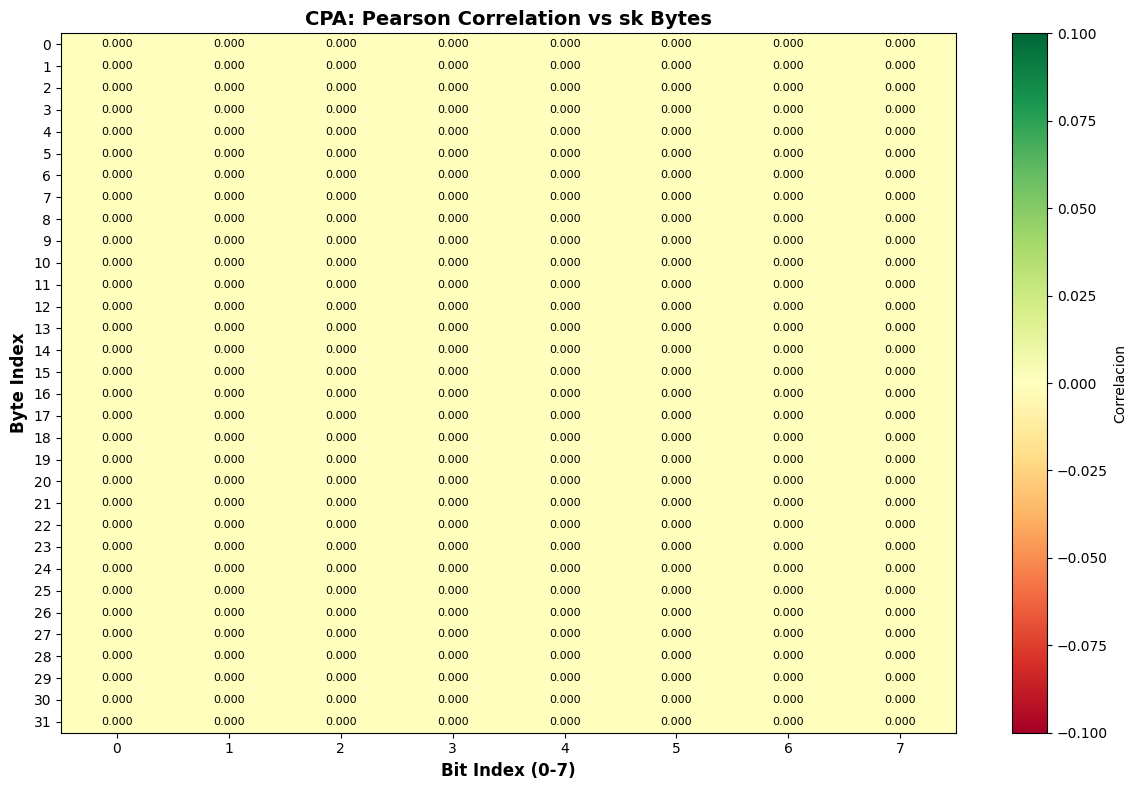

Top bytes by leakage strength:

idx | max_corr | sk_byte | hw_real | strong_bits
----------------------------------------------------------------------
00  |  0.0000 | 0x9E   |   5    | -
01  |  0.0000 | 0xE6   |   5    | -
02  |  0.0000 | 0xC3   |   4    | -
03  |  0.0000 | 0x79   |   5    | -
04  |  0.0000 | 0x1C   |   3    | -
05  |  0.0000 | 0x70   |   3    | -
06  |  0.0000 | 0x26   |   3    | -
07  |  0.0000 | 0x36   |   4    | -
08  |  0.0000 | 0x94   |   3    | -
09  |  0.0000 | 0x51   |   3    | -
10  |  0.0000 | 0x05   |   2    | -
11  |  0.0000 | 0x3F   |   6    | -
----------------------------------------------------------------------
Average max_corr: 0.0000
Max global: 0.0000
Traces: 100, Window: [11583, 11603] (20 samples)

✓ CPA analysis finished!


In [29]:
# =============================================================================
# CPA PER-BIT: Correlation Power Analysis (versión vectorizada)
# CPA PER-BIT: Correlation Power Analysis (vectorized version)
# =============================================================================
from scipy.stats import pearsonr

mean_trace = np.mean(traces, axis=0)
std_trace = np.std(traces, axis=0)

peak = int(np.argmax(std_trace))
w0 = max(0, peak - 10)
w1 = min(traces.shape[1], peak + 10)

print(f"Variation peak at sample {peak}, analyzed window [{w0}, {w1})")
print(f"Analysis range: {w1 - w0} samples\n")

if "sk" not in globals():
    raise RuntimeError("Variable sk not available")

sk_arr = np.frombuffer(bytes(sk), dtype=np.uint8)
nbytes = min(32, len(sk_arr))
window_trace = traces[:, w0:w1]

print(f"Trace window: {window_trace.shape}")
print("Procesando CPA por bit...\n")

# =========================================================================
# CPA vectorizado: para cada byte y bit
# Vectorized CPA: for each byte and bit
# =========================================================================
correlation_matrix = np.zeros((nbytes, 8))

for byte_idx in range(nbytes):
    sk_byte = int(sk_arr[byte_idx])
    
    for bit_idx in range(8):
        bit_value = (sk_byte >> bit_idx) & 1
        
        # Crear vector binario: 1 si bit coincide, 0 si no
        # Create binary vector: 1 if bit matches, 0 otherwise
        bit_model = np.array([bit_value] * len(window_trace), dtype=np.float32)
        
        # Calcular media de potencia para cada muestra de la ventana
        # Compute average power for each sample in the window
        trace_mean_per_sample = np.mean(window_trace, axis=0)
        
        # Correlacion entre modelo binario y media de trazas
        # Correlation between binary model and mean traces
        try:
            # Usar correlacion sobre la traza media diferenciada
            # Use correlation on the differentiated mean trace
            diff_model = bit_model - np.mean(bit_model)
            trace_diff = trace_mean_per_sample - np.mean(trace_mean_per_sample)
            
            numerator = np.sum(diff_model * trace_diff)
            denom_trace = np.sqrt(np.sum(diff_model**2) * np.sum(trace_diff**2) + 1e-12)
            
            if denom_trace > 1e-9:
                corr = abs(numerator / denom_trace)
            else:
                corr = 0.0
        except:
            corr = 0.0
        
        correlation_matrix[byte_idx, bit_idx] = corr
    
    if (byte_idx + 1) % 8 == 0:
        print(f"  ✓ {byte_idx + 1}/{nbytes} bytes processed")

print("\n✓ CPA completado\n")

# =========================================================================
# Visualizacion
# Visualization
# =========================================================================
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(correlation_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=np.max(correlation_matrix))

ax.set_xlabel("Bit Index (0-7)", fontsize=12, fontweight="bold")
ax.set_ylabel("Byte Index", fontsize=12, fontweight="bold")
ax.set_xticks(range(8))
ax.set_yticks(range(nbytes))

for i in range(nbytes):
    for j in range(8):
        color = "white" if correlation_matrix[i, j] > np.max(correlation_matrix)*0.5 else "black"
        ax.text(j, i, f"{correlation_matrix[i, j]:.3f}",
                ha="center", va="center", color=color, fontsize=8)

fig.colorbar(im, ax=ax, label="Correlacion")
plt.title("CPA: Pearson Correlation vs sk Bytes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================================================================
# Ranking
# Ranking
# =========================================================================
byte_scores = np.max(correlation_matrix, axis=1)
hw_real = np.array([bin(int(sk_arr[i])).count("1") for i in range(nbytes)], dtype=int)

print("=" * 70)
print("Top bytes by leakage strength:\n")
print("idx | max_corr | sk_byte | hw_real | strong_bits")
print("-" * 70)

ranked = sorted(enumerate(byte_scores), key=lambda x: x[1], reverse=True)
for rank, (byte_idx, score) in enumerate(ranked[:12]):
    strong_bits = [f"b{j}" for j in range(8) if correlation_matrix[byte_idx, j] > 0.05]
    bits_str = ",".join(strong_bits) if strong_bits else "-"
    print(f"{byte_idx:02d}  | {score:7.4f} | 0x{int(sk_arr[byte_idx]):02X}   |   {hw_real[byte_idx]}    | {bits_str}")

print("-" * 70)
print(f"Average max_corr: {np.mean(byte_scores):.4f}")
print(f"Max global: {np.max(correlation_matrix):.4f}")
print(f"Traces: {len(traces)}, Window: [{w0}, {w1}] ({w1-w0} samples)")
print("\n✓ CPA analysis finished!")

Traces used: (100, 100000)
SK bytes: 1632
Analysis over full trace; no window cropping.


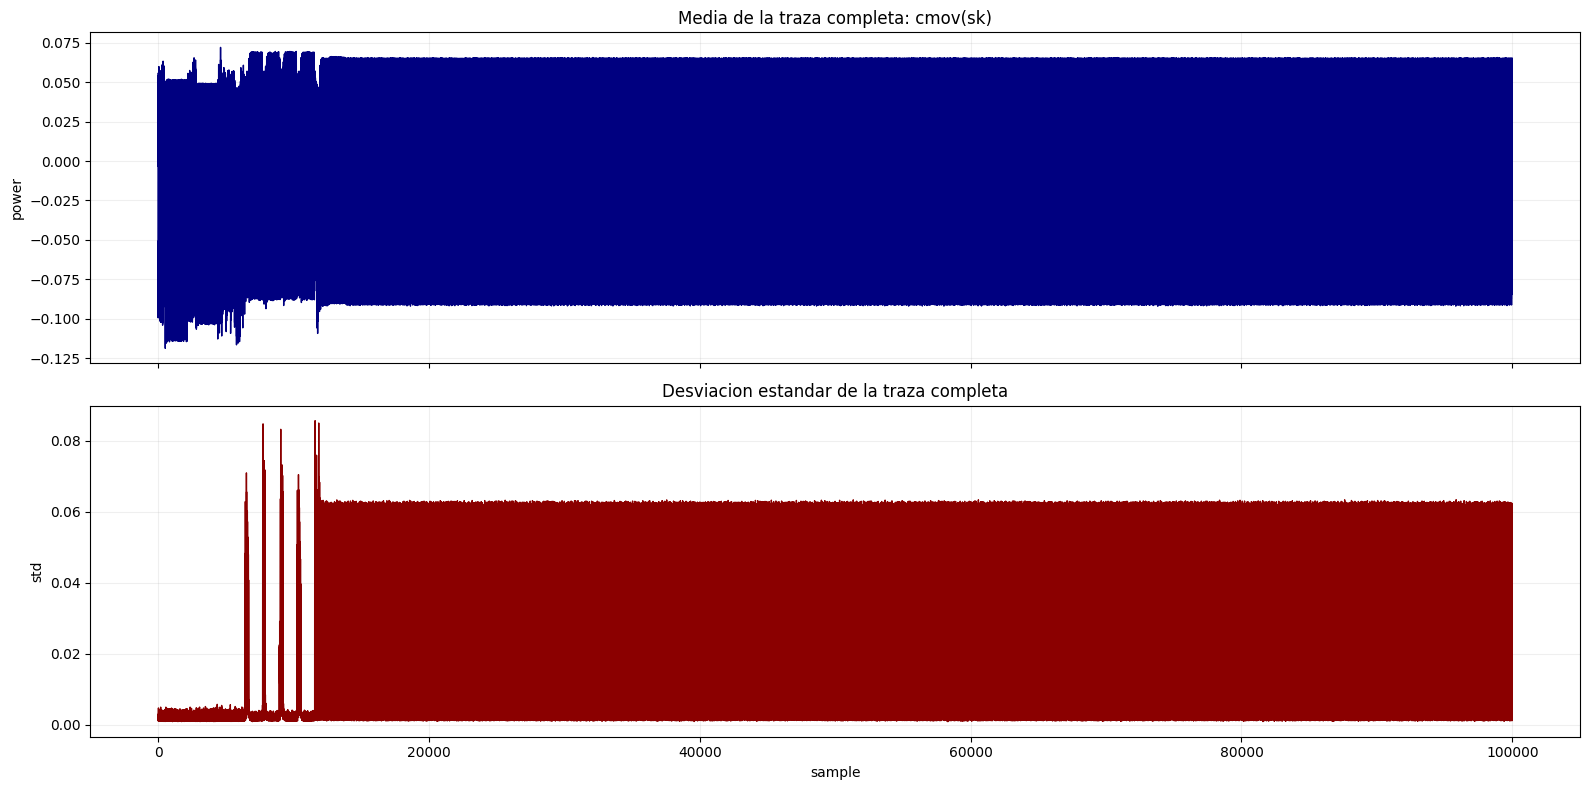


=== True profile of loaded key ===
Analyzed bytes: 1632
Mean HW per byte: 3.820
Min/max HW: 0 / 8


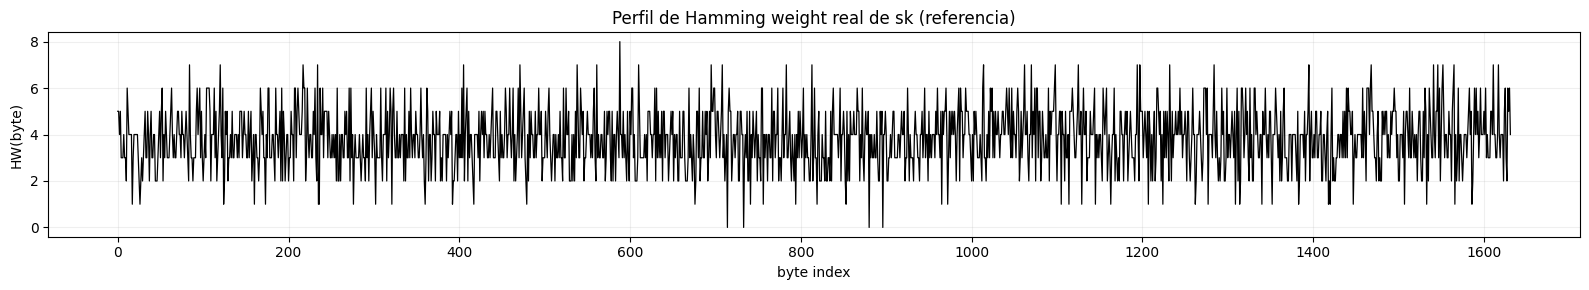


✓ The capture covers the full cmov over sk.
Note: with a single fixed key there is not enough variation to distinguish 1/0 bits
from trace correlation alone; calibration or controlled patterns are needed.


In [30]:
# Analisis de traza completa: cmov(sk) sin ventanas
# Full-trace analysis: cmov(sk) without windowing
if "cmov_sk_traces" in globals() and isinstance(cmov_sk_traces, np.ndarray) and len(cmov_sk_traces) > 0:
    analysis_traces = cmov_sk_traces
    print("Using dedicated cmov(sk) traces [cmd 0x0C]")
elif "traces" in globals() and isinstance(traces, np.ndarray) and len(traces) > 0:
    analysis_traces = traces
    print("Warning: cmov_sk_traces not available; using 'traces' from previous flow")
else:
    raise RuntimeError("No traces available. Run the cmov(sk) capture cell first (cmd 0x0C).")

cmov_mean_trace = np.mean(analysis_traces, axis=0)
cmov_std_trace = np.std(analysis_traces, axis=0)

print(f"Traces used: {analysis_traces.shape}")
if "sk" not in globals():
    raise RuntimeError("Variable sk not available. Load vectors first.")
print(f"SK bytes: {len(sk)}")
print("Analysis over full trace; no window cropping.")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(cmov_mean_trace, color="navy", linewidth=1.0)
axes[0].set_title("Media de la traza completa: cmov(sk)")
axes[0].set_ylabel("power")
axes[0].grid(alpha=0.2)

axes[1].plot(cmov_std_trace, color="darkred", linewidth=1.0)
axes[1].set_title("Desviacion estandar de la traza completa")
axes[1].set_xlabel("sample")
axes[1].set_ylabel("std")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

sk_arr = np.frombuffer(bytes(sk), dtype=np.uint8)
hw_sk = np.array([bin(int(v)).count("1") for v in sk_arr], dtype=np.int16)

print("\n=== True profile of loaded key ===")
print(f"Analyzed bytes: {len(sk_arr)}")
print(f"Mean HW per byte: {np.mean(hw_sk):.3f}")
print(f"Min/max HW: {np.min(hw_sk)} / {np.max(hw_sk)}")

plt.figure(figsize=(16, 3))
plt.plot(hw_sk, color="black", linewidth=0.9)
plt.title("Perfil de Hamming weight real de sk (referencia)")
plt.xlabel("byte index")
plt.ylabel("HW(byte)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("\n✓ The capture covers the full cmov over sk.")
print("Note: with a single fixed key there is not enough variation to distinguish 1/0 bits")
print("from trace correlation alone; calibration or controlled patterns are needed.")

In [31]:
# Captura dedicada: cmov completo sobre sk (cmd 0x0C)
# Dedicated capture: full cmov over sk (cmd 0x0C)
cmov_sk_traces = []
cmov_sk_acks = []
cmov_sk_cap_timeouts = 0
cmov_sk_ack_timeouts = 0
cmov_sk_consecutive_failures = 0

print(f"Errors before capture cmov(sk): {scope.errors}")

target.reset_comms()
target.flush()

for i in range(SPA_N_TRACES):
    scope.arm()
    target.send_cmd(0x0C, 0x00, bytearray())

    timed_out = scope.capture()
    if timed_out:
        cmov_sk_cap_timeouts += 1
        cmov_sk_consecutive_failures += 1
        print(f"[cap timeout] trace {i}")
        _ = ss2_wait_ack_filtered(target, tries=2, timeout=100)
        if cmov_sk_consecutive_failures >= 5:
            print("[resync] too many consecutive timeouts, resetting comms")
            target.reset_comms()
            target.flush()
            cmov_sk_consecutive_failures = 0
        continue

    trace = np.array(scope.get_last_trace(), dtype=np.float32)
    ack = ss2_wait_ack_filtered(target, tries=6, timeout=60000)
    if ack is None:
        cmov_sk_ack_timeouts += 1
        cmov_sk_consecutive_failures += 1
        print(f"[ack timeout] trace {i}")
        target.flush()
        if cmov_sk_consecutive_failures >= 5:
            print("[resync] too many ACK failures, resetting comms")
            target.reset_comms()
            target.flush()
            cmov_sk_consecutive_failures = 0
        continue

    cmov_sk_consecutive_failures = 0
    cmov_sk_traces.append(trace)
    cmov_sk_acks.append(ack)

    if (i + 1) % 10 == 0:
        print(f"captured {i+1}/{SPA_N_TRACES}")

cmov_sk_traces = np.array(cmov_sk_traces, dtype=np.float32)
cmov_sk_acks = np.array(cmov_sk_acks, dtype=np.int16)

print("\n=== cmov(sk) capture summary ===")
print(f"valid traces: {len(cmov_sk_traces)}")
print(f"capture timeouts: {cmov_sk_cap_timeouts}")
print(f"ack timeouts: {cmov_sk_ack_timeouts}")
if len(cmov_sk_acks) > 0:
    print(f"ACK=0x00: {np.sum(cmov_sk_acks==0)} | ACK=0x01: {np.sum(cmov_sk_acks==1)}")
print(f"Errors after capture: {scope.errors}")

if len(cmov_sk_traces) == 0:
    raise RuntimeError("No valid cmov(sk) traces were captured")

Errors before capture cmov(sk): sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = False
extclk error    = False
trace errors    = False

captured 10/100
captured 20/100
captured 30/100
captured 40/100
captured 50/100
captured 60/100
captured 70/100
captured 80/100
captured 90/100
captured 100/100

=== cmov(sk) capture summary ===
valid traces: 100
capture timeouts: 0
ack timeouts: 0
ACK=0x00: 100 | ACK=0x01: 0
Errors after capture: sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = False
extclk error    = False
trace errors    = False



In [32]:
# Quick CPA Debug: verificar estructura de datos
# Quick CPA Debug: verify data structure
print("DEBUG: Checking data availability...")
print(f"traces shape: {traces.shape}")
print(f"len(sk): {len(sk)}")

sk_arr = np.frombuffer(bytes(sk), dtype=np.uint8)
print(f"sk_arr shape: {sk_arr.shape}")
print(f"sk_arr[:8] = {sk_arr[:8]}")

mean_trace = np.mean(traces, axis=0)
std_trace = np.std(traces, axis=0)
peak = int(np.argmax(std_trace))
print(f"\nMean trace shape: {mean_trace.shape}")
print(f"Peak index: {peak}")

w0 = max(0, peak - 180)
w1 = min(traces.shape[1], peak + 180)
print(f"Window: [{w0}, {w1}] = {w1-w0} samples")

# Simple correlation test
window = traces[:, w0:w1]
print(f"Window shape: {window.shape}")
print("✓ Data OK")

DEBUG: Checking data availability...
traces shape: (100, 100000)
len(sk): 1632
sk_arr shape: (1632,)
sk_arr[:8] = [158 230 195 121  28 112  38  54]

Mean trace shape: (100000,)
Peak index: 11593
Window: [11413, 11773] = 360 samples
Window shape: (100, 360)
✓ Data OK


## Session Wrap-Up / Cierre de Sesion

**English:** Final cleanup and disconnection to release the hardware resources cleanly.
**Español:** Limpieza final y desconexion para liberar los recursos de hardware de forma limpia.
**Português:** Limpeza final e desconexão para liberar os recursos de hardware de forma limpa.


In [ ]:
scope.dis()
target.dis()

## Husky-Specific Notes / Notas Especificas de Husky

**English:** Additional Husky guidance for advanced usage beyond the core ML-KEM capture path.
**Español:** Guia adicional de Husky para uso avanzado mas alla del flujo principal de captura ML-KEM.
**Português:** Orientações adicionais do Husky para uso avançado além do fluxo principal de captura ML-KEM.
